In [2]:
import sys

import importlib
from functools import partial

import matplotlib.pyplot as plt
import numpy as np  
from IPython.display import display
import pandas as pd 

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx

In [3]:
from new_src.eval import eval_summary
from new_src.utils import eval_plot

from new_src.graph_level_dist import neural_approx_ged_dist

from new_src.graph_sampler import GraphSampler
from new_src.trainer import Trainer

from new_src.criteria import (
    WeightedCriterion, 
    ClassScoreCriterion, 
    EmbeddingCriterion, 
    BudgetPenalty,
    KLDivergencePenalty, 
    NormPenalty 
)

import new_src.dataAdapter
from new_src.dataAdapter import load_dataset
importlib.reload(new_src.dataAdapter)

import new_src.explainee
from new_src.explainee import fit_explainee
importlib.reload(new_src.explainee)

import new_src.ged_dataset
importlib.reload(new_src.ged_dataset)

from new_src.ged_dataset import create_and_save_ged_dataset, plot_graph_pair

import new_src.simgnn
importlib.reload(new_src.simgnn)

from new_src.simgnn import SimGNN, train_simgnn

from new_src.agg_instance import (
    build_explainer,
    aggregate_instance_explanations,
    run_eval_summary,
    plot_eval,
)

In [4]:
# Reproducibility
SEED = 123123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True 
np.random.seed(SEED)

In [5]:
def run_GNNInt(
    cls_idx, 
    max_nodes, 
    data, 
    mean_embeds,
    explainee 
):
    trainer = Trainer(
        sampler=(
            s := GraphSampler(
                    max_nodes=max_nodes,
                    num_node_cls=len(data.NODE_CLS),
                    num_edge_cls=len(data.EDGE_CLS), 
                    temperature=0.15,
                    learn_node_feat=len(data.NODE_CLS) > 0, 
                    learn_edge_feat=len(data.EDGE_CLS) > 0, 
            )
        ),
        discriminator=explainee,
        criterion=WeightedCriterion([
            dict(key="logits", 
                criterion=ClassScoreCriterion(
                    class_idx=cls_idx, mode='maximize'
                ), 
                weight=1
            ),
            dict(key="embeds", 
                criterion=EmbeddingCriterion(
                    target_embedding=mean_embeds[cls_idx]
                ), 
                weight=50
            ),
            dict(key="omega", criterion=NormPenalty(order=1), weight=1),
            dict(key="omega", criterion=NormPenalty(order=2), weight=1),
            dict(key="theta_pairs", 
                criterion=KLDivergencePenalty(
                    binary=True
                ), 
                weight=4
            ),
        ]),
        optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
        scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
        dataset=data,
        budget_penalty=BudgetPenalty(budget=20, order=2, beta=1),
        device="cpu"
    )

    trainer.train(
        iterations=200, 
        target_probs={cls_idx: (0.9, 1.0)},
        target_size=30,
        w_budget_init=0.5,
        w_budget_inc=1.1,
        w_budget_dec=0.95,
        k_samples=32
    )

    example = trainer.evaluate(threshold=0.5)

    example = from_networkx(example)

    if "label" in example: 
        example.x = F.one_hot(
            example.label, num_classes=len(data.NODE_CLS)
        ).float()

    if "edge_label" in example: 
        example.edge_attr = F.one_hot(
            example.edge_label, num_classes=len(data.EDGE_CLS)
        ).float()

    example.y = torch.tensor(cls_idx).float()
    
    return example

def eval_GNNInt(data, mean_embeds, explainee, ged_model):
    graphs_0 = [
        run_GNNInt(
            cls_idx=0, 
            max_nodes=20, 
            data=data, 
            mean_embeds=mean_embeds, 
            explainee=explainee, 
        ) for _ in range(25)
    ]

    graphs_1 = [
        run_GNNInt(
            cls_idx=1, 
            max_nodes=20, 
            data=data, 
            mean_embeds=mean_embeds, 
            explainee=explainee, 
        ) for _ in range(25)
    ]

    cls_split = data.split_by_class() 
    
    dist_to_0 = neural_approx_ged_dist(cls_split[0], ged_model)
    dist_to_1 = neural_approx_ged_dist(cls_split[1], ged_model)

    eval_summary(
        explainee=explainee, 
        gen_graphs_0=graphs_0,
        gen_graphs_1=graphs_1, 
        obs_graphs_0=cls_split[0], 
        obs_graphs_1=cls_split[1], 
        dist_to_0=dist_to_0, 
        dist_to_1=dist_to_1, 
    )

    eval_plot(
        explainee, 
        graphs_0, 
        graphs_1, 
        obs_graphs_0=cls_split[0], 
        obs_graphs_1=cls_split[1],
        ged_model=ged_model, 
        dataset=data,
        layout="kamada"
    )

In [6]:
def eval_agg_explainer(explainee, data, ged_model):
    explainer = build_explainer(
        explainee,
        algorithm="gnnexplainer",  # try "pgexplainer", Captum variants, etc.
        algorithm_kwargs={"epochs": 50},
        explanation_type="model",
        node_mask_type="object",
        edge_mask_type="object",
    )

    aggregation = aggregate_instance_explanations(
        data,
        explainer,
        explainee=explainee,
        strategy="wl_topk",
        strategy_kwargs={"wl_hops": 2, "top_p": 0.25, "min_edges": 4},
    )

    cls_split = data.split_by_class() 
    
    dist_to_0 = neural_approx_ged_dist(cls_split[0], ged_model)
    dist_to_1 = neural_approx_ged_dist(cls_split[1], ged_model)
    
    summary_score = run_eval_summary(
        explainee,
        aggregation,
        observed_class_0=cls_split[0],
        observed_class_1=cls_split[1],
        dist_to_0=dist_to_0,
        dist_to_1=dist_to_1,
    )


    plot_eval(
        explainee,
        aggregation,
        observed_class_0=cls_split[0],
        observed_class_1=cls_split[1],
        ged_model=ged_model,
        dataset=data,
        max_pairs=3,
    )

In [7]:
def prep_data(dataset_name):

    data = load_dataset(dataset_name)
    cls_split = data.split_by_class()


    explainee, _ = fit_explainee(
        dataset_name = dataset_name,
        root="data",
        hidden=64,
        layers=3,
        dropout=0.2,
        epochs=100,
        batch_size=16,
        lr=1e-3,
        device="cpu"
    )


    # Extract embeddings. 
    mean_embeds = [
        torch.cat([explainee(batch.to("cpu"))["embeds"]
                for batch in DataLoader(subset, batch_size=64)])
            .mean(dim=0)
        for subset in cls_split
    ]
    mean_embeds = [m.detach() for m in mean_embeds]


    ged_dataset = create_and_save_ged_dataset(
        data, 
        out_path=None, 
        n_perturbations=1,
        node_add_prob=0.5,
        node_remove_prob=0.5,
        edge_add_prob=0.1, 
        edge_remove_prob=0.1
    )

    print(f"Created GED dataset with {len(ged_dataset)} pairs.")

    model = SimGNN(in_dim=len(data.NODE_CLS))

    train_simgnn(
        model=(m := model), 
        data=ged_dataset, 
        batch_size=16, 
        optimizer=(o := torch.optim.Adam(m.parameters(), lr=1e-3)),
        scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
        epochs=25, 
        device="cpu"
    )

    return data, explainee, mean_embeds, model,  

# Mutag

In [8]:
data, explainee, mean_embeds, model = prep_data("MUTAG")

[001/100] train_loss=0.6461  val_acc=0.684
[002/100] train_loss=0.5977  val_acc=0.684
[003/100] train_loss=0.5718  val_acc=0.684
[004/100] train_loss=0.5622  val_acc=0.684
[005/100] train_loss=0.5511  val_acc=0.684
[006/100] train_loss=0.5266  val_acc=0.895
[007/100] train_loss=0.5130  val_acc=0.842
[008/100] train_loss=0.5005  val_acc=0.842
[009/100] train_loss=0.4871  val_acc=0.789
[010/100] train_loss=0.5102  val_acc=0.789
[011/100] train_loss=0.4991  val_acc=0.842
[012/100] train_loss=0.5294  val_acc=0.789
[013/100] train_loss=0.4745  val_acc=0.842
[014/100] train_loss=0.4669  val_acc=0.789
[015/100] train_loss=0.4776  val_acc=0.842
[016/100] train_loss=0.4486  val_acc=0.842
[017/100] train_loss=0.4624  val_acc=0.842
[018/100] train_loss=0.4621  val_acc=0.789
[019/100] train_loss=0.4408  val_acc=0.842
[020/100] train_loss=0.4692  val_acc=0.842
[021/100] train_loss=0.4640  val_acc=0.842
[022/100] train_loss=0.4311  val_acc=0.842
[023/100] train_loss=0.4515  val_acc=0.842
[024/100] t

Training SimGNN:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 001 | Loss: 0.1566 | MSE(norm): 0.1566 | MSE(raw): 78.5354 | Corr(norm): 0.0439 | Corr(raw): 0.4135
Epoch 002 | Loss: 0.1400 | MSE(norm): 0.1400 | MSE(raw): 69.8715 | Corr(norm): 0.0612 | Corr(raw): 0.4783
Epoch 003 | Loss: 0.1355 | MSE(norm): 0.1355 | MSE(raw): 59.7825 | Corr(norm): -0.0135 | Corr(raw): 0.4476
Epoch 004 | Loss: 0.1154 | MSE(norm): 0.1154 | MSE(raw): 47.7176 | Corr(norm): 0.3154 | Corr(raw): 0.6798
Epoch 005 | Loss: 0.1162 | MSE(norm): 0.1162 | MSE(raw): 50.0963 | Corr(norm): 0.2599 | Corr(raw): 0.6555
Epoch 006 | Loss: 0.1172 | MSE(norm): 0.1172 | MSE(raw): 52.8705 | Corr(norm): 0.2702 | Corr(raw): 0.6325
Epoch 007 | Loss: 0.1132 | MSE(norm): 0.1132 | MSE(raw): 47.0786 | Corr(norm): 0.3170 | Corr(raw): 0.6836
Epoch 008 | Loss: 0.1026 | MSE(norm): 0.1026 | MSE(raw): 41.9937 | Corr(norm): 0.3583 | Corr(raw): 0.6912
Epoch 009 | Loss: 0.1062 | MSE(norm): 0.1062 | MSE(raw): 43.4730 | Corr(norm): 0.4019 | Corr(raw): 0.7192
Epoch 010 | Loss: 0.1040 | MSE(norm): 0.1040 

## GNNInterpreter

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Prediction Interval Class 0 0.983956515789032 +/- 0.03312349319458008

Prediction Interval Class 1 0.23145537078380585 +/- 0.12205951660871506

Counterfactual Shift to Class 0 0.3232988715171814 +/- 0.46324872970581055

Counterfactual Shift to Class 1 0.4835589528083801 +/- 0.22318334877490997

Class 0 Perturbation Sensitivity 0.00844359677284956 +/- 0.026251692324876785

Class 1 Perturbation Sensitivity 0.00880635716021061 +/- 0.013897723518311977

Relative Distance to Class 0 0.005922911688685417 +/- 0.029894458130002022 

Relative Distance to Class 1 -0.00729479780420661 +/- 0.030845964327454567 



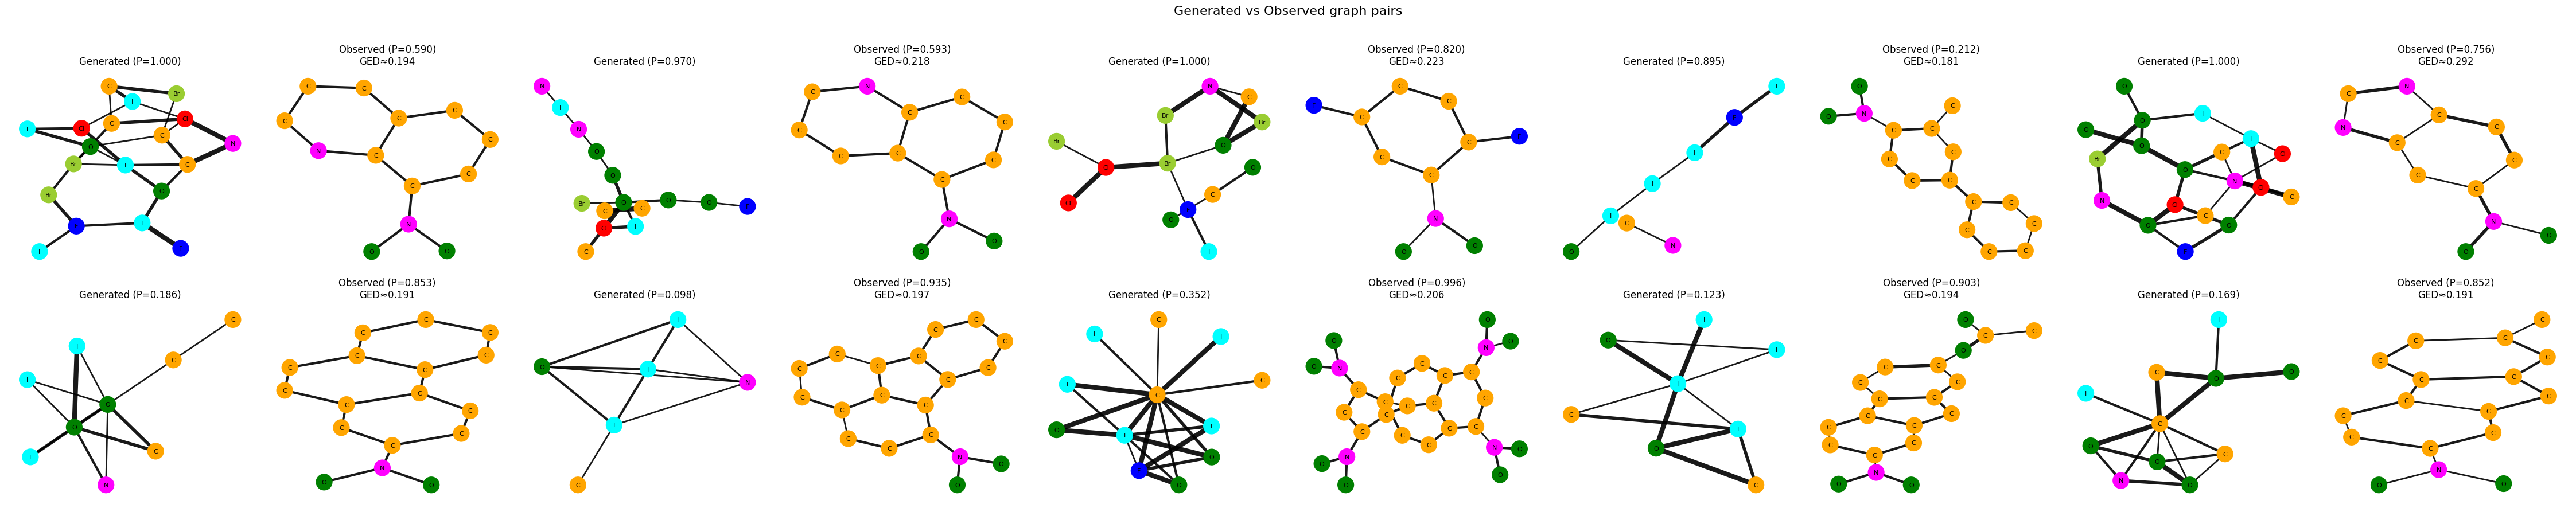

In [9]:
eval_GNNInt(
    data=data, 
    mean_embeds=mean_embeds, 
    explainee=explainee, 
    ged_model=model
)

## Aggregated Explainer 

Prediction Interval Class 0 0.9415513873100281 +/- 0.02830350399017334

Prediction Interval Class 1 0.07579553872346878 +/- 0.03205759450793266

Counterfactual Shift to Class 0 -0.06598800420761108 +/- 0.07801486551761627

Counterfactual Shift to Class 1 0.2382107526063919 +/- 0.15738992393016815

Class 0 Perturbation Sensitivity 0.011705892160534859 +/- 0.016832925379276276

Class 1 Perturbation Sensitivity 0.01177717000246048 +/- 0.020893651992082596

Relative Distance to Class 0 -0.0035923325922340155 +/- 0.015933888033032417 

Relative Distance to Class 1 0.0038823396898806095 +/- 0.007854227907955647 



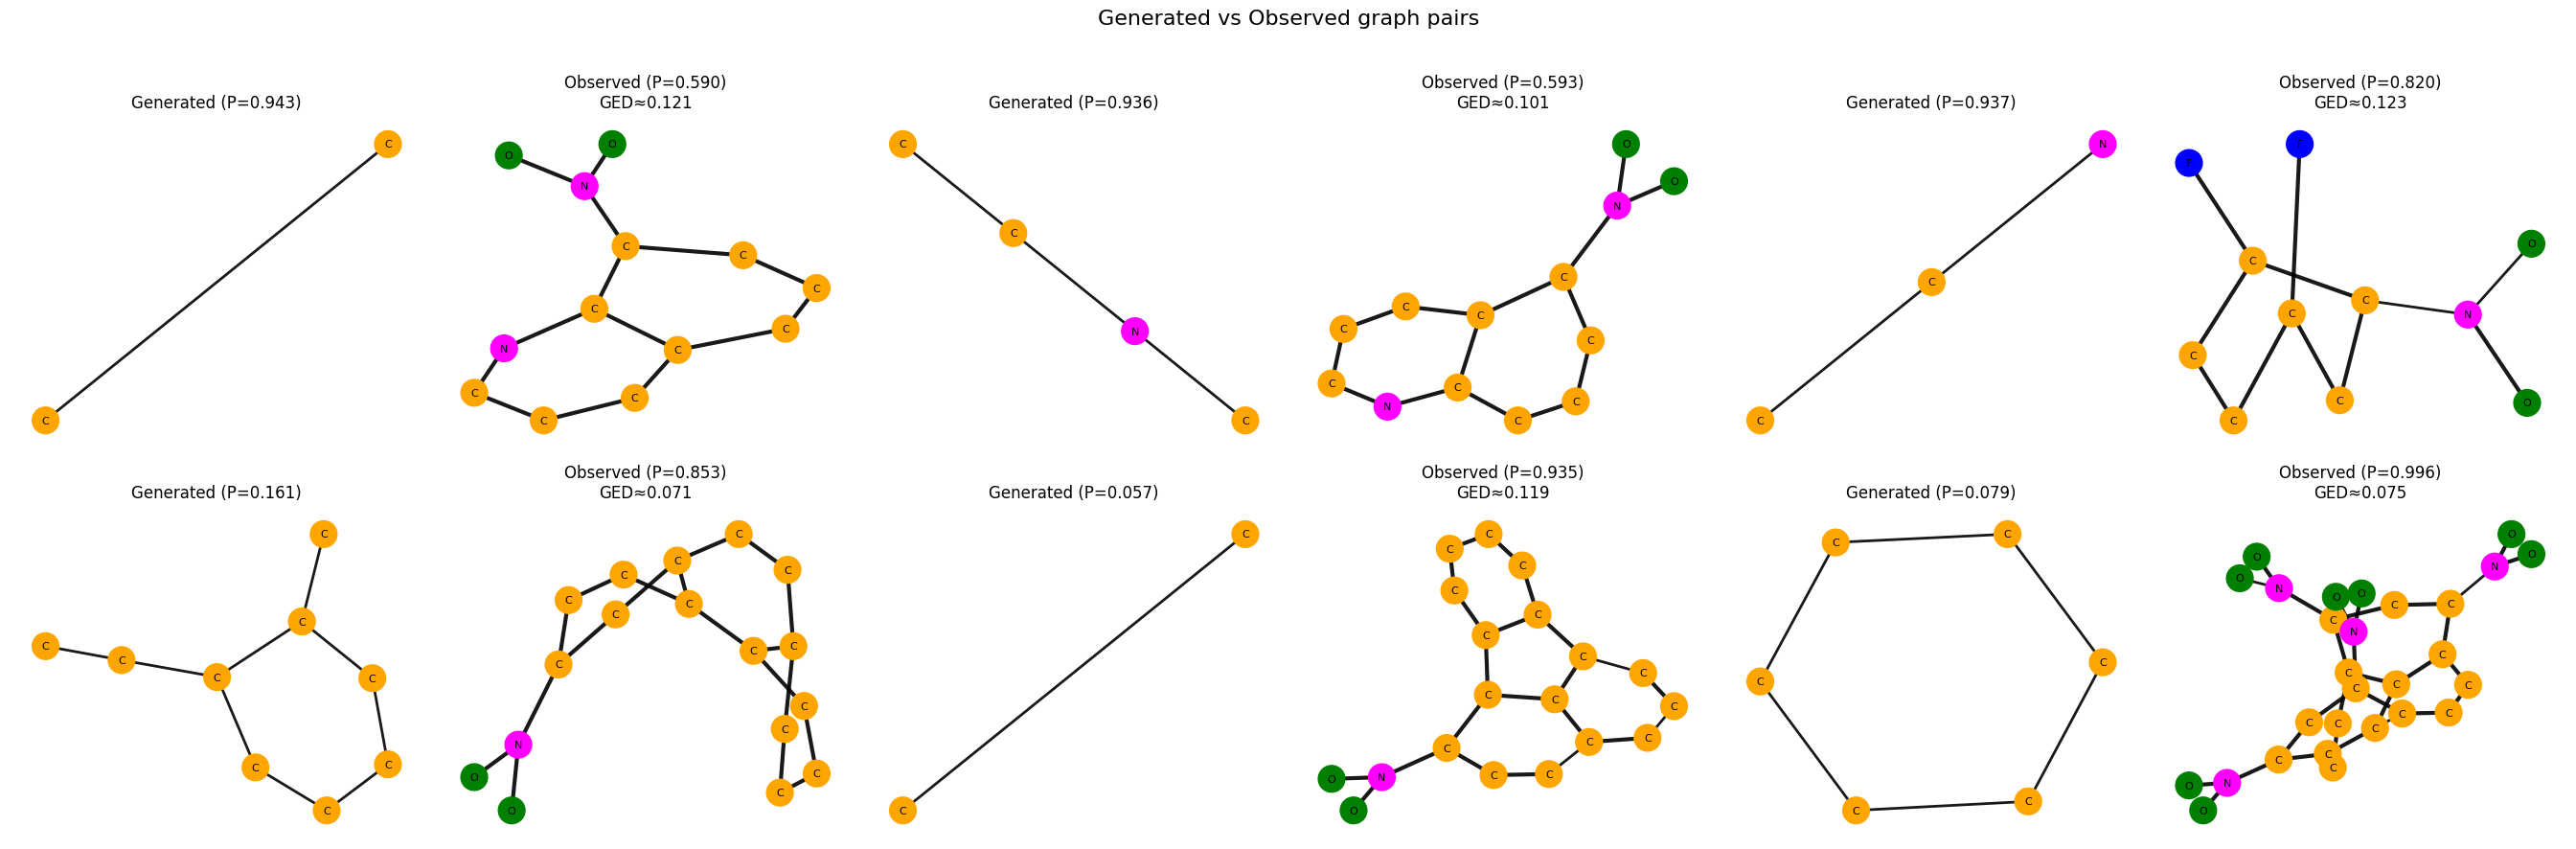

In [10]:
eval_agg_explainer(
    data=data, 
    explainee=explainee,
    ged_model=model
)

# BA-2MOTIFS

In [11]:
data, explainee, mean_embeds, model = prep_data("BA-2MOTIFS")

[001/100] train_loss=0.6955  val_acc=0.430
[002/100] train_loss=0.6975  val_acc=0.430
[003/100] train_loss=0.6953  val_acc=0.430
[004/100] train_loss=0.6948  val_acc=0.430
[005/100] train_loss=0.6945  val_acc=0.570
[006/100] train_loss=0.6944  val_acc=0.570
[007/100] train_loss=0.6936  val_acc=0.430
[008/100] train_loss=0.6942  val_acc=0.570
[009/100] train_loss=0.6935  val_acc=0.570
[010/100] train_loss=0.6937  val_acc=0.570
[011/100] train_loss=0.6941  val_acc=0.570
[012/100] train_loss=0.6933  val_acc=0.430
[013/100] train_loss=0.6938  val_acc=0.430
[014/100] train_loss=0.6950  val_acc=0.570
[015/100] train_loss=0.6937  val_acc=0.570
[016/100] train_loss=0.6935  val_acc=0.570
[017/100] train_loss=0.6950  val_acc=0.570
[018/100] train_loss=0.6935  val_acc=0.570
[019/100] train_loss=0.6936  val_acc=0.430
[020/100] train_loss=0.6936  val_acc=0.570
[021/100] train_loss=0.6934  val_acc=0.570
[022/100] train_loss=0.6934  val_acc=0.570
[023/100] train_loss=0.6939  val_acc=0.430
[024/100] t

Training SimGNN:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 001 | Loss: 0.1592 | MSE(norm): 0.1592 | MSE(raw): 124.1501 | Corr(norm): 0.1592 | Corr(raw): 0.4364
Epoch 002 | Loss: 0.1309 | MSE(norm): 0.1309 | MSE(raw): 99.7316 | Corr(norm): 0.3342 | Corr(raw): 0.5837
Epoch 003 | Loss: 0.1251 | MSE(norm): 0.1251 | MSE(raw): 95.8927 | Corr(norm): 0.3837 | Corr(raw): 0.6040
Epoch 004 | Loss: 0.1062 | MSE(norm): 0.1062 | MSE(raw): 78.6546 | Corr(norm): 0.5151 | Corr(raw): 0.6912
Epoch 005 | Loss: 0.0894 | MSE(norm): 0.0894 | MSE(raw): 65.8885 | Corr(norm): 0.6183 | Corr(raw): 0.7506
Epoch 006 | Loss: 0.0594 | MSE(norm): 0.0594 | MSE(raw): 44.4441 | Corr(norm): 0.7656 | Corr(raw): 0.8398
Epoch 007 | Loss: 0.0531 | MSE(norm): 0.0531 | MSE(raw): 40.0918 | Corr(norm): 0.7951 | Corr(raw): 0.8569
Epoch 008 | Loss: 0.0511 | MSE(norm): 0.0511 | MSE(raw): 37.9299 | Corr(norm): 0.8024 | Corr(raw): 0.8650
Epoch 009 | Loss: 0.0437 | MSE(norm): 0.0437 | MSE(raw): 33.1779 | Corr(norm): 0.8346 | Corr(raw): 0.8830
Epoch 010 | Loss: 0.0541 | MSE(norm): 0.0541 

## GNNInterpreter

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Prediction Interval Class 0 0.49992477893829346 +/- 1.5504894690820947e-05

Prediction Interval Class 1 0.5000728368759155 +/- 2.0852765374002047e-05

Counterfactual Shift to Class 0 -8.531868843419943e-06 +/- 1.5625902960891835e-05

Counterfactual Shift to Class 1 9.78207572188694e-06 +/- 1.8560262105893344e-05

Class 0 Perturbation Sensitivity 4.87399120174814e-06 +/- 7.225502486107871e-06

Class 1 Perturbation Sensitivity 8.910894393920898e-06 +/- 2.1968338842270896e-05

Relative Distance to Class 0 -0.04660962149500847 +/- 0.07127171009778976 

Relative Distance to Class 1 0.05125093087553978 +/- 0.06938662379980087 



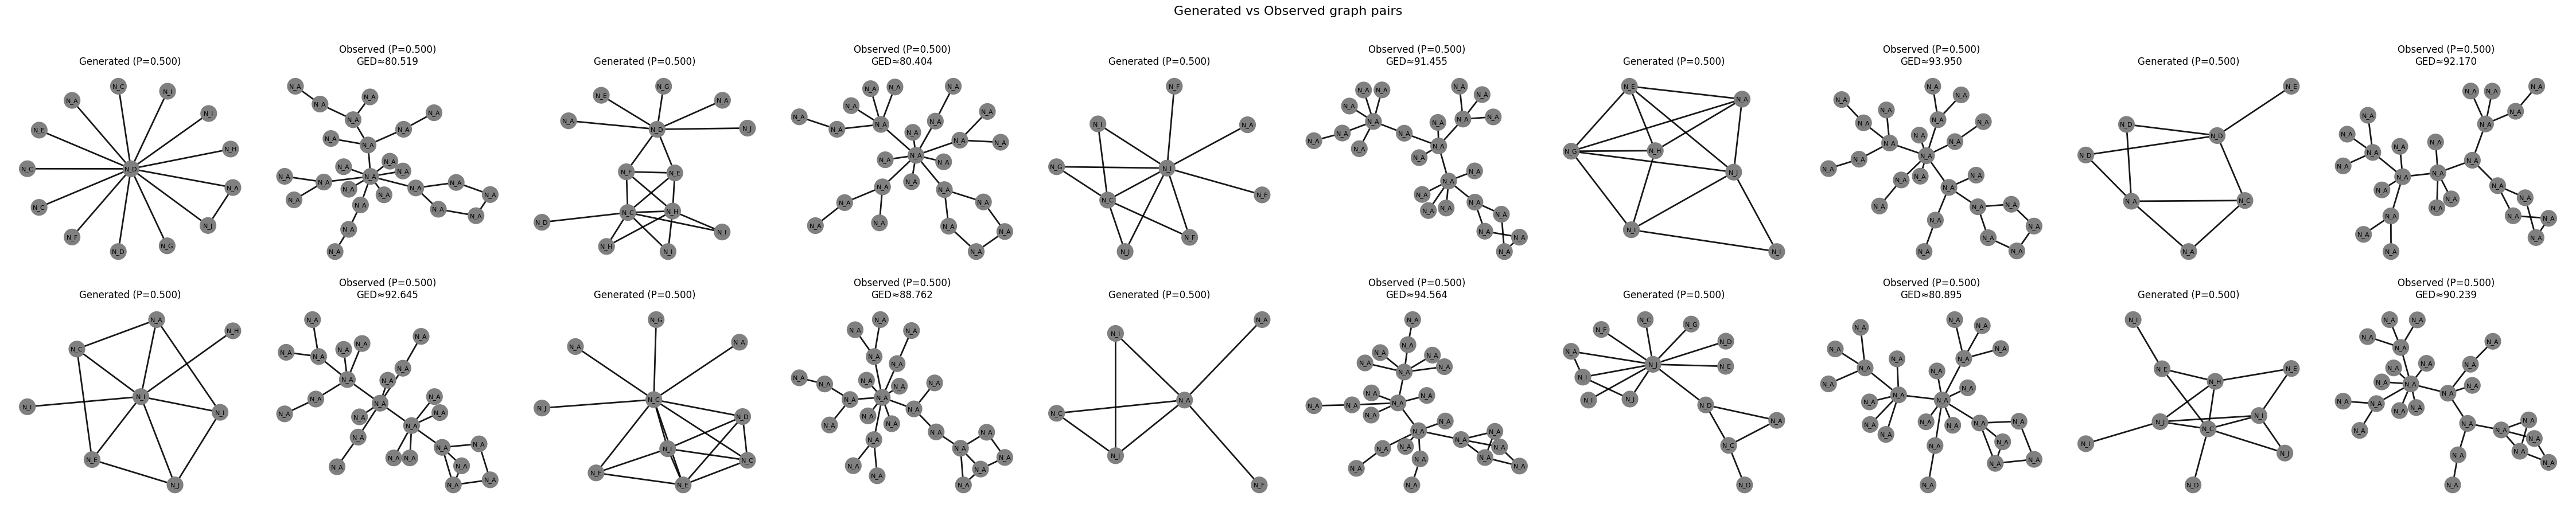

In [12]:
eval_GNNInt(
    data=data, 
    mean_embeds=mean_embeds, 
    explainee=explainee, 
    ged_model=model
)

## Aggregated Explainer

In [13]:
eval_agg_explainer(
    data=data, 
    explainee=explainee,
    ged_model=model
)

KeyboardInterrupt: 

# PROTEINS

In [14]:
data, explainee, mean_embeds, model = prep_data("PROTEINS")

[001/100] train_loss=0.5944  val_acc=0.730
[002/100] train_loss=0.5574  val_acc=0.712
[003/100] train_loss=0.5662  val_acc=0.694
[004/100] train_loss=0.5448  val_acc=0.685
[005/100] train_loss=0.5340  val_acc=0.640
[006/100] train_loss=0.5489  val_acc=0.685
[007/100] train_loss=0.5270  val_acc=0.703
[008/100] train_loss=0.5169  val_acc=0.622
[009/100] train_loss=0.5259  val_acc=0.676
[010/100] train_loss=0.5204  val_acc=0.685
[011/100] train_loss=0.5257  val_acc=0.703
[012/100] train_loss=0.5314  val_acc=0.712
[013/100] train_loss=0.5116  val_acc=0.730
[014/100] train_loss=0.5114  val_acc=0.676
[015/100] train_loss=0.5055  val_acc=0.685
[016/100] train_loss=0.5162  val_acc=0.703
[017/100] train_loss=0.5259  val_acc=0.712
[018/100] train_loss=0.5112  val_acc=0.676
[019/100] train_loss=0.5081  val_acc=0.685
[020/100] train_loss=0.5080  val_acc=0.694
[021/100] train_loss=0.5096  val_acc=0.676
[022/100] train_loss=0.5005  val_acc=0.721
[023/100] train_loss=0.4971  val_acc=0.649
[024/100] t

Training SimGNN:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 001 | Loss: 49.3095 | MSE(norm): 49.3095 | MSE(raw): 64668820.0000 | Corr(norm): 0.1174 | Corr(raw): -0.3744
Epoch 002 | Loss: 182.8848 | MSE(norm): 182.8848 | MSE(raw): 223210592.0000 | Corr(norm): 0.1239 | Corr(raw): 0.0780
Epoch 003 | Loss: 20.5784 | MSE(norm): 20.5784 | MSE(raw): 66882648.0000 | Corr(norm): 0.0971 | Corr(raw): 0.5356
Epoch 004 | Loss: 16.0969 | MSE(norm): 16.0969 | MSE(raw): 50139288.0000 | Corr(norm): 0.0889 | Corr(raw): 0.5712
Epoch 005 | Loss: 14.1150 | MSE(norm): 14.1150 | MSE(raw): 16576699.0000 | Corr(norm): 0.1073 | Corr(raw): 0.3332
Epoch 006 | Loss: 2.3642 | MSE(norm): 2.3642 | MSE(raw): 6319505.0000 | Corr(norm): 0.2030 | Corr(raw): 0.6507
Epoch 007 | Loss: 0.5865 | MSE(norm): 0.5865 | MSE(raw): 181380.7500 | Corr(norm): 0.2245 | Corr(raw): 0.8449
Epoch 008 | Loss: 1.2253 | MSE(norm): 1.2253 | MSE(raw): 824307.1875 | Corr(norm): 0.1325 | Corr(raw): 0.5933
Epoch 009 | Loss: 0.5790 | MSE(norm): 0.5790 | MSE(raw): 254513.9375 | Corr(norm): 0.0247 | Cor

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Prediction Interval Class 0 0.28937971591949463 +/- 0.1554272323846817

Prediction Interval Class 1 0.9206489324569702 +/- 0.04007027670741081

Counterfactual Shift to Class 0 0.2281751036643982 +/- 0.19902563095092773

Counterfactual Shift to Class 1 -0.05224127322435379 +/- 0.07310263067483902

Class 0 Perturbation Sensitivity 0.01088907103985548 +/- 0.014843742363154888

Class 1 Perturbation Sensitivity 0.05636707693338394 +/- 0.06686969846487045

Relative Distance to Class 0 -0.012254701927304268 +/- 0.05771553888916969 

Relative Distance to Class 1 0.012170881032943726 +/- 0.07292452454566956 



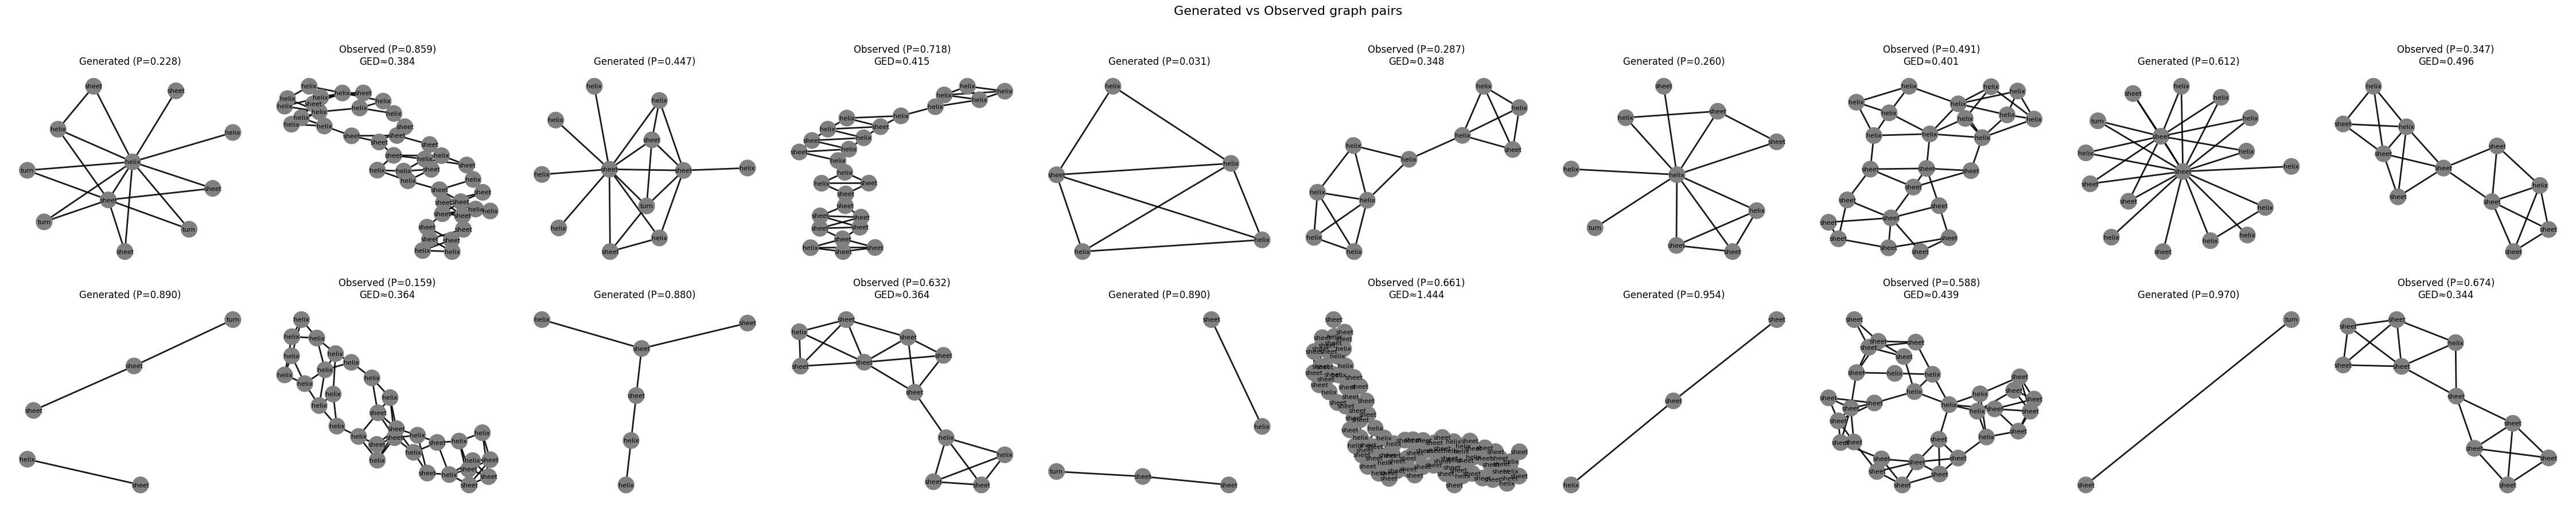

: 

In [ ]:
eval_GNNInt(
    data=data, 
    mean_embeds=mean_embeds, 
    explainee=explainee, 
    ged_model=model
)

In [ ]:
eval_agg_explainer(
    data=data, 
    explainee=explainee,
    ged_model=model
)

# NCI1

# BZR_MD

# COX2_MD

# ER_MD

# DHRF_MD